In [1]:
import pandas as pd
import numpy as np
 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder # 원 - 핫 인코딩
le = LabelEncoder()

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

from sklearn.model_selection import train_test_split 

from sklearn.metrics import accuracy_score , confusion_matrix , classification_report

In [3]:
df = sns.load_dataset("penguins")

df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


<Figure size 1000x600 with 0 Axes>

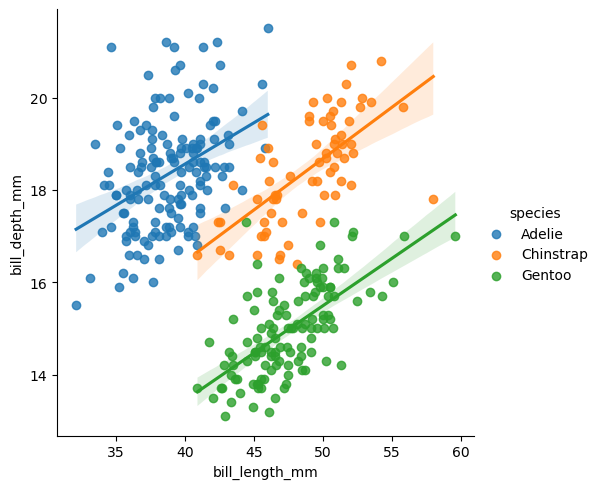

In [8]:
plt.figure(figsize = (10, 6))

sns.lmplot(data = df, x='bill_length_mm', y='bill_depth_mm', hue = 'species')
plt.show()

In [5]:
# TODO 3-2: 종별 숫자형 변수 평균

numeric_cols = df.select_dtypes(include=['number']).columns
species_averages = df.groupby("species")[numeric_cols].mean()
print("종별 숫자형 변수 평균:\n{}".format(species_averages))

종별 숫자형 변수 평균:
           bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
species                                                                 
Adelie          38.791391      18.346358         189.953642  3700.662252
Chinstrap       48.833824      18.420588         195.823529  3733.088235
Gentoo          47.504878      14.982114         217.186992  5076.016260


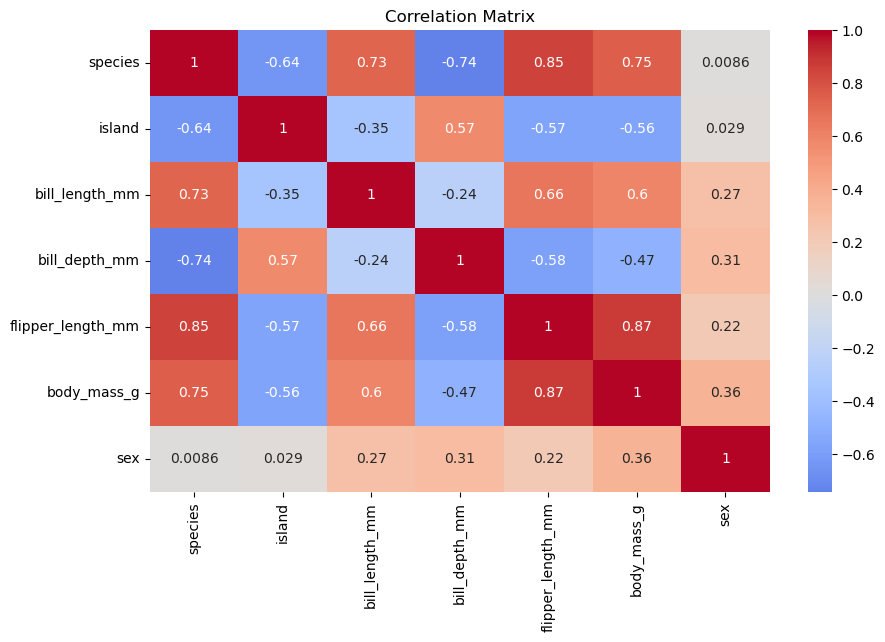

In [6]:
# TODO 3-5: 상관계수 행렬과 히트맵

import numpy as np
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
for col in df_encoded.select_dtypes(include=['object']).columns:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col].astype(str))
correlation_matrix = df_encoded.corr()
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

In [9]:
regression_target = "body_mass_g"
regression_numeric_features = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm"]
regression_categorical_features = ["species", "island", "sex"]
regression_features = regression_numeric_features + regression_categorical_features

In [20]:
from sklearn.model_selection import train_test_split

df = df.dropna(subset=[regression_target]+regression_features)

X_reg = df[regression_features]
y_reg = df[regression_target]

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_reg, y_reg,test_size=0.2, random_state = 42)

In [21]:
# TODO 6-1

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression

reg_numeric_transformer = Pipeline([("scaler", StandardScaler())])
reg_categorical_transformer = Pipeline([("encoder", OneHotEncoder(handle_unknown="ignore"))])
reg_preprocessor = ColumnTransformer([
    ("numeric", reg_numeric_transformer, regression_numeric_features),
    ("categorical", reg_categorical_transformer, regression_categorical_features)
])
linear_model = Pipeline([
    ("preprocessor", reg_preprocessor),
    ("regressor", LinearRegression())
])


In [22]:
# TODO 8-1 : 6단계에서 만든 `linear_model`을 학습하고, 테스트 데이터에서 MAE, RMSE, R²를 계산하세요.

from sklearn.metrics import mean_squared_error, r2_score

lr = linear_model.fit(X_reg_train, y_reg_train)
y_pred_linear = lr.predict(X_reg_test)
linear_mse = mean_squared_error(y_reg_test, y_pred_linear)
linear_rmse = linear_mse ** 0.5
linear_r2 = r2_score(y_reg_test, y_pred_linear)

linear_metrics = pd.DataFrame({
    "Model": ["Linear Regression"],
    "RMSE": [linear_rmse],
    "R2": [linear_r2]
})
print(f"Linear Regression - RMSE: {linear_rmse}, R2: {linear_r2}")

Linear Regression - RMSE: 255.74907911734914, R2: 0.8961688345769453


,actual,predicted,residual,abs_residual
81,4700.0,3957.650255,742.349745,742.349745
260,3950.0,4585.405037,-635.405037,635.405037
119,3325.0,3886.545936,-561.545936,561.545936
235,5850.0,5361.205214,488.794786,488.794786
187,3900.0,3454.962919,445.037081,445.037081
116,2900.0,3330.284573,-430.284573,430.284573
268,5100.0,4672.904426,427.095574,427.095574
82,3800.0,3402.842112,397.157888,397.157888
331,5950.0,5566.850930,383.149070,383.149070
51,4300.0,3926.530576,373.469424,373.469424


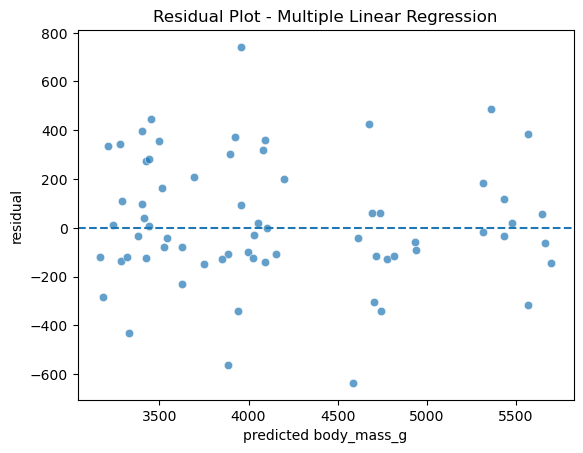

In [23]:
# TODO 11-1 : 테스트 데이터의 예측값과 잔차를 계산하고, 실제값과 예측값의 차이와 잔차를 확인 할 수 있도록 그래프를 그리세요.

linear_pred = lr.predict(X_reg_test)
linear_residuals = y_reg_test - linear_pred
residual_df = pd.DataFrame({
    "actual": y_reg_test,
    "predicted": linear_pred,
    "residual": linear_residuals,
    "abs_residual": linear_residuals.abs()
})
display(residual_df.sort_values("abs_residual", ascending=False).head(10))

sns.scatterplot(x=residual_df["predicted"], y=residual_df["residual"], alpha=0.7)
plt.axhline(0, linestyle="--")
plt.title("Residual Plot - Multiple Linear Regression")
plt.xlabel("predicted body_mass_g")
plt.ylabel("residual")
plt.show()
